In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [3]:
# loading the data

df = pd.read_csv("../data/raw/heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [9]:
# checking dimension
df.shape

(918, 12)

In [4]:
# checking null values

df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [8]:
# checking duplicates

print(df.duplicated().sum())

0


In [10]:
# basic info

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [11]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


<Axes: xlabel='HeartDisease'>

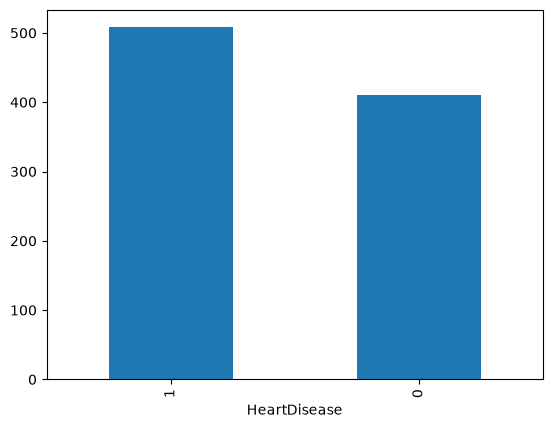

In [12]:
# checking if target variable is balanced or imbalanced

df['HeartDisease'].value_counts().plot(kind = 'bar')

In [13]:
# checking if cholesterol is 0 , as it is not possible => replace it with mean

ch_mean = df.loc[df['Cholesterol'] != 0, 'Cholesterol'].mean()

df['Cholesterol'] = df['Cholesterol'].replace(0, ch_mean)
df['Cholesterol'] = df['Cholesterol'].round(2)

In [14]:
# similary, for restingBP column

bp_mean = df.loc[df['RestingBP'] != 0, 'RestingBP'].mean()
df['RestingBP'] = df['RestingBP'].replace(0, bp_mean)
df['RestingBP'] = df['RestingBP'].round(2)

In [15]:
# plotting (histogram) for columns age, restingBP, cholesterol and maxHR

def plotting(var, num):
    plt.subplot(2, 2, num)
    sns.histplot(
        df[var],
        kde = True
    )

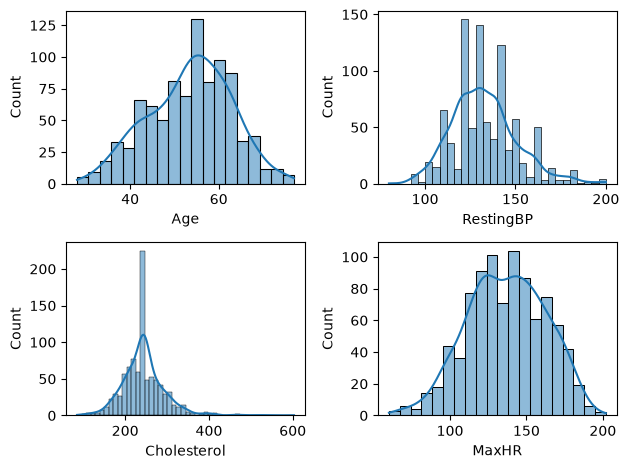

In [17]:
plotting('Age', 1)
plotting('RestingBP', 2)
plotting('Cholesterol', 3)
plotting('MaxHR', 4)

plt.tight_layout()

<Axes: xlabel='Sex', ylabel='count'>

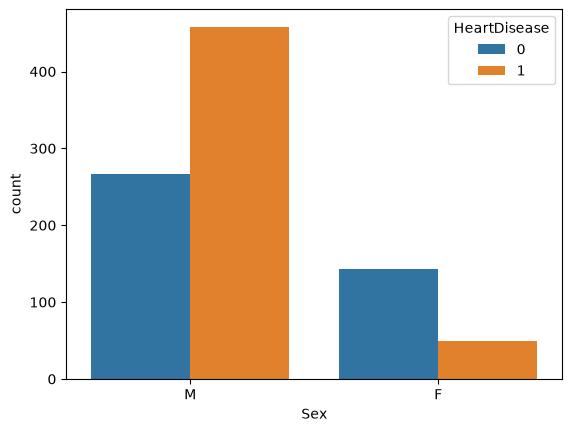

In [18]:
# Relationship between gender and heart disease

sns.countplot(
    x = df['Sex'],
    hue = df['HeartDisease']
)

<Axes: xlabel='ChestPainType', ylabel='count'>

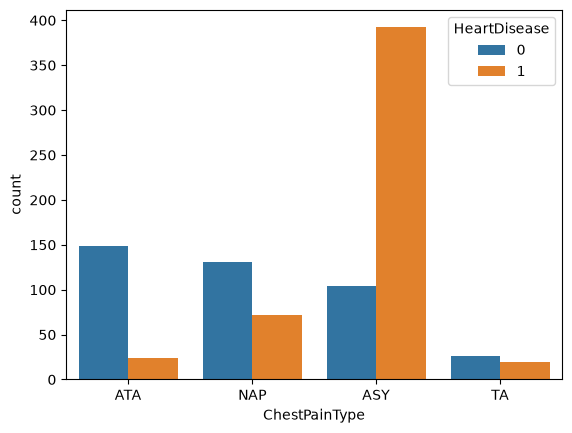

In [19]:
# realtionship between chest pain type and heart disease

sns.countplot(
    x = df['ChestPainType'],
    hue = df['HeartDisease']
)

<Axes: xlabel='FastingBS', ylabel='count'>

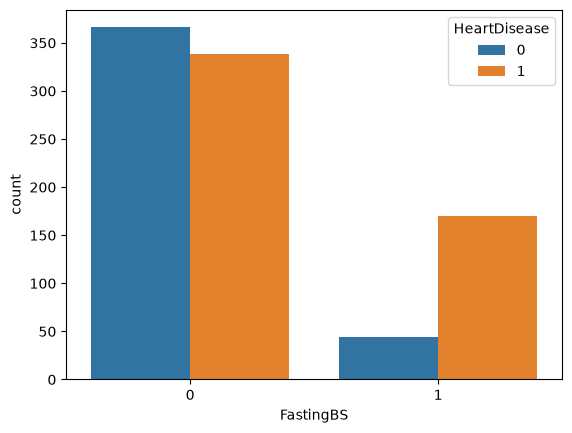

In [20]:
# Relationship between Fasting Blood Sugar and Heart Disease

sns.countplot(
    x = df['FastingBS'],
    hue = df['HeartDisease']
)

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

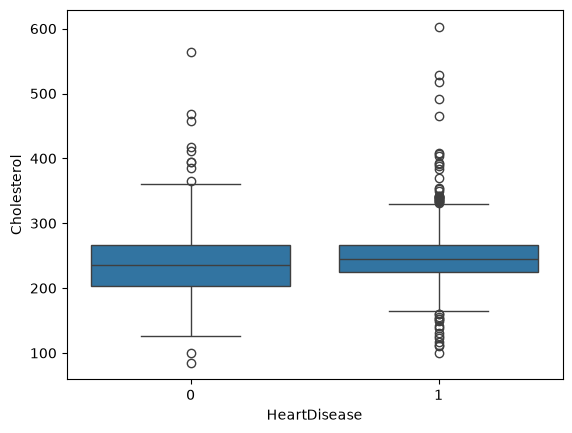

In [21]:
# visualising cholesterol vs heart disease through boxplot

sns.boxplot(
    x = df['HeartDisease'],
    y = df['Cholesterol'],
    data = df
)


<Axes: xlabel='HeartDisease', ylabel='Age'>

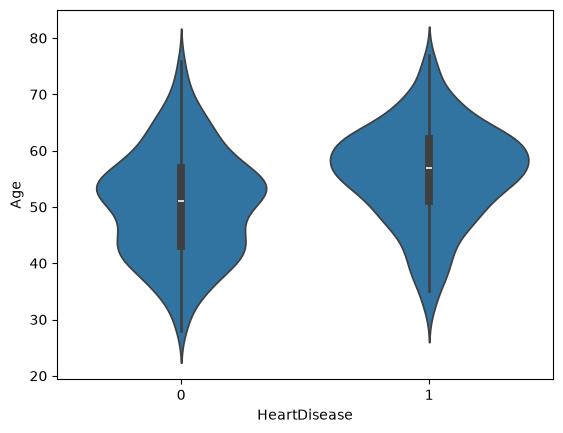

In [22]:
# Visualising the distribution of age vs heartdisease through violinplot

sns.violinplot(
    x = df['HeartDisease'],
    y = df['Age'],
    data = df
)

<Axes: >

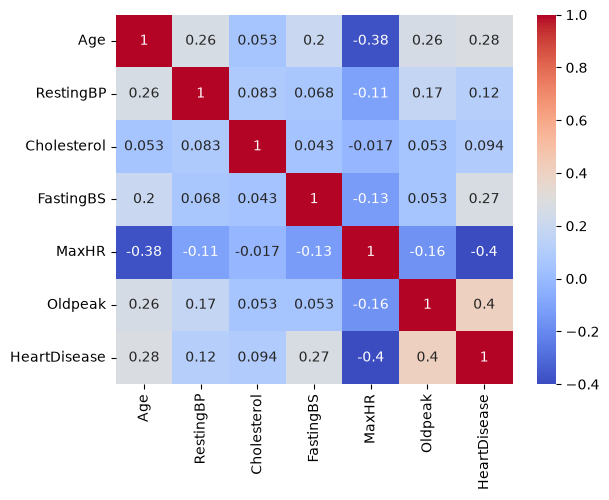

In [26]:
# correlation through heatmap

sns.heatmap(
    df.corr(
        numeric_only = True,
    ),
    annot = True,
    cmap = 'coolwarm'
    
)

In [29]:
# splitting the test and train dataset

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    random_state = 42,
    test_size  = 0.2,
    stratify = df['HeartDisease']
)

In [31]:
# saving the test and train dataset

train_df.to_csv('../data/raw/train.csv')
test_df.to_csv('../data/raw/test.csv')